# Mutual Fund Analytics Capstone

## Exploratory Data Analysis (EDA)

Author: Sunanda Reddy

Period: 2022-2026

2. Load Libraries (Code)

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

3. Load Data (Code)

In [6]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")
category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")
folios = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

In [9]:
nav["date"] = pd.to_datetime(nav["date"])

In [ ]:

# nav_trend.png
nav_plot = nav.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="NAV Trends 2022-2026"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    annotation_text="Correction"
)

fig.show()
fig.write_html("../reports/nav_trend.html")

# EDA Finding 1

Most mutual fund schemes showed a strong upward NAV trend during 2023, indicating a broad market bull run.

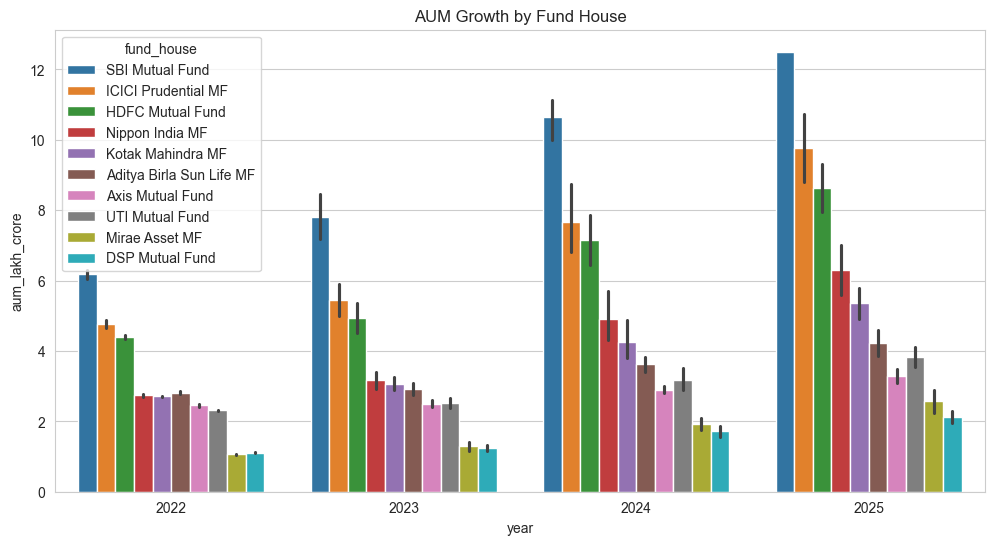

In [ ]:
# aum_growth.png
aum["year"] = pd.to_datetime(
    aum["date"]
).dt.year
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.savefig(
    "../reports/aum_growth.png"
)

plt.show()

# EDA Finding 2

SBI Mutual Fund maintained the highest Assets Under Management (AUM) across the analysis period.

In [ ]:
# sip_trend.png
sip["month"] = pd.to_datetime(
    sip["month"]
)
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

peak = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text="All Time High"
)
plt.savefig(
    "../reports/monthly_sip_inflows.png"
)
fig.show()

<Figure size 640x480 with 0 Axes>

# EDA Finding 3

Monthly SIP inflows displayed consistent growth and reached record levels by the end of 2025.

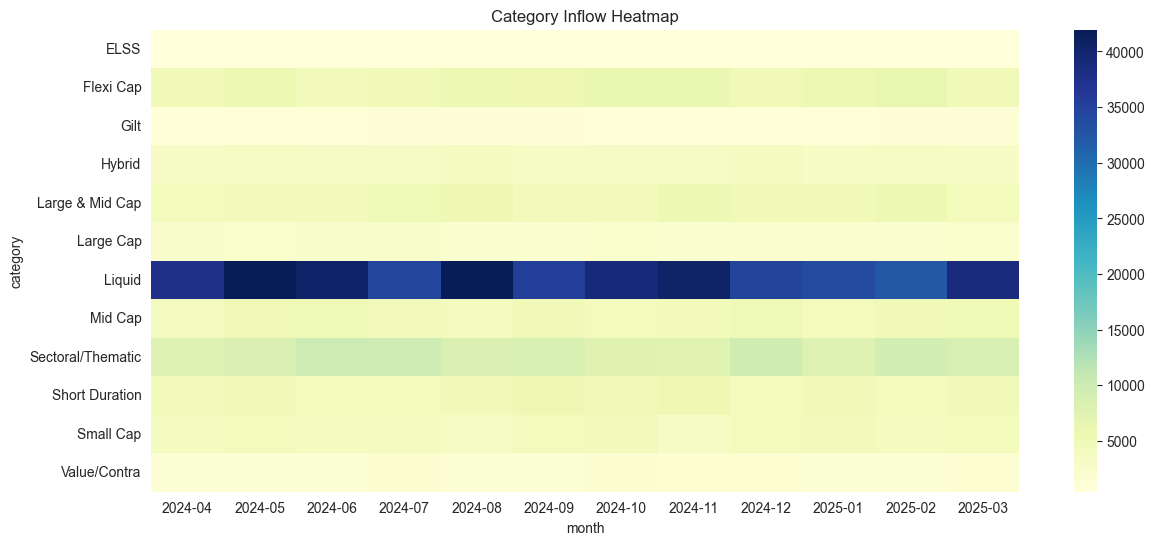

In [ ]:
# category_heatmap.png
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)
plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig(
    "../reports/category_heatmap.png"
)

plt.show()

# EDA Finding 4

Equity-oriented fund categories attracted the highest net inflows compared with debt and hybrid categories.

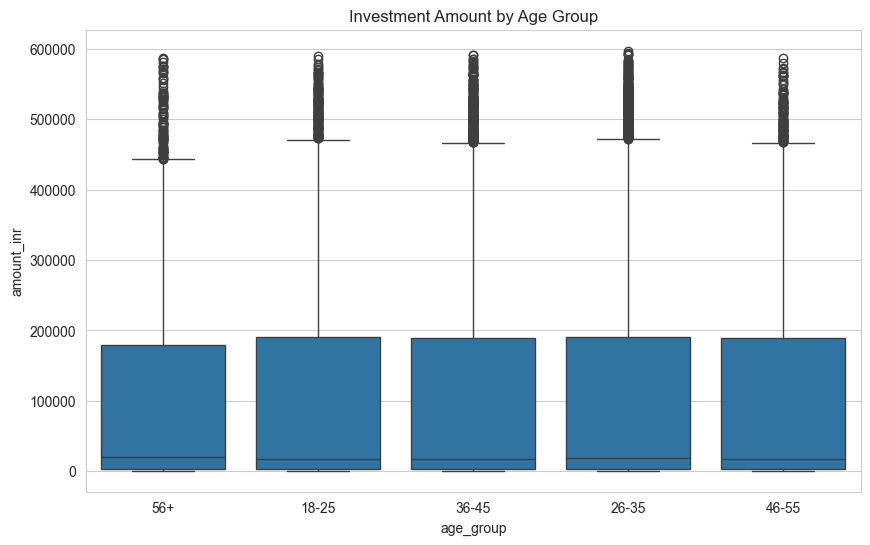

In [ ]:
# age_group_boxplot.png
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "Investment Amount by Age Group"
)

plt.savefig(
    "../reports/age_group_boxplot.png"
)

plt.show()

# EDA Finding 6

Investment amounts vary significantly across age groups, with middle-aged investors contributing larger transaction values.

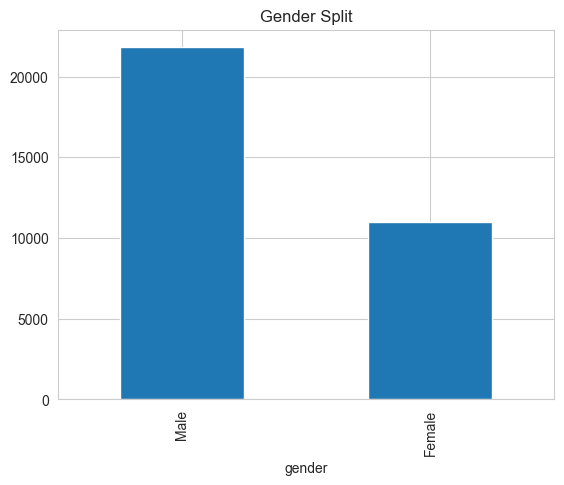

In [ ]:
# gender_split.png
transactions["gender"].value_counts().plot(
    kind="bar"
)

plt.title("Gender Split")

plt.savefig(
    "../reports/gender_split.png"
)

plt.show()

# EDA Finding 7

Investment participation is distributed across genders, showing broad investor engagement.

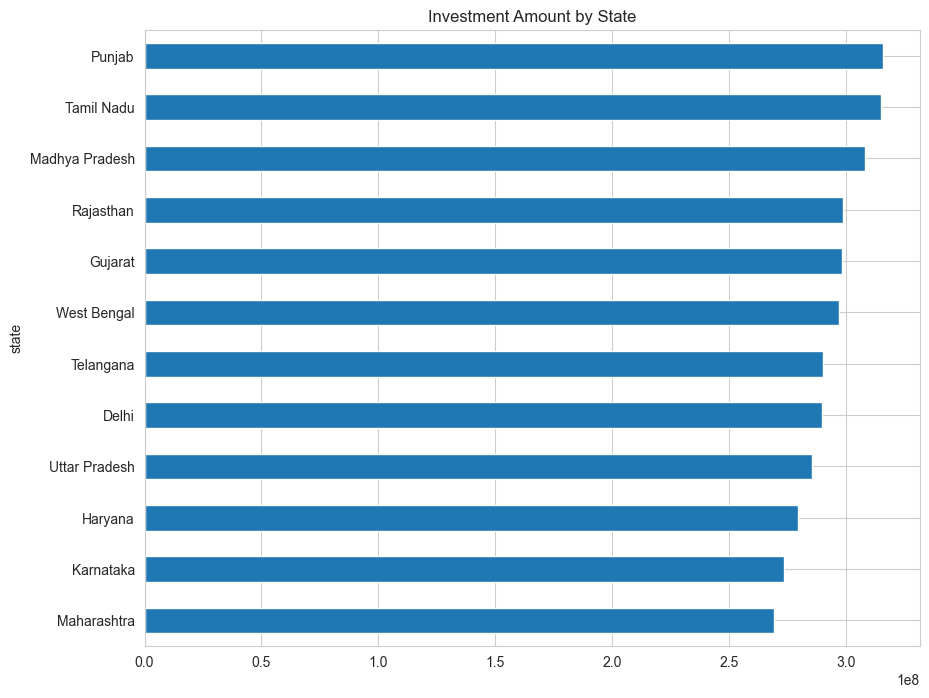

In [ ]:
# state_distribution.png
state_amt = (
    transactions
    .groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values()
)
plt.figure(figsize=(10,8))

state_amt.plot(kind="barh")

plt.title(
    "Investment Amount by State"
)

plt.savefig(
    "../reports/state_distribution.png"
)

plt.show()

# EDA Finding 8

A small number of states account for a substantial share of total mutual fund investments.

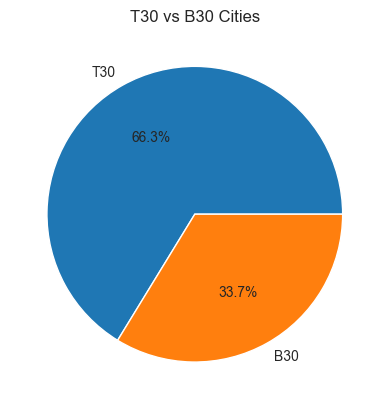

In [ ]:
# t30_b30.png
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "T30 vs B30 Cities"
)

plt.savefig(
    "../reports/t30_b30.png"
)

plt.show()

# EDA Finding 9

T30 cities contribute a larger share of investments than B30 cities, indicating stronger urban participation.

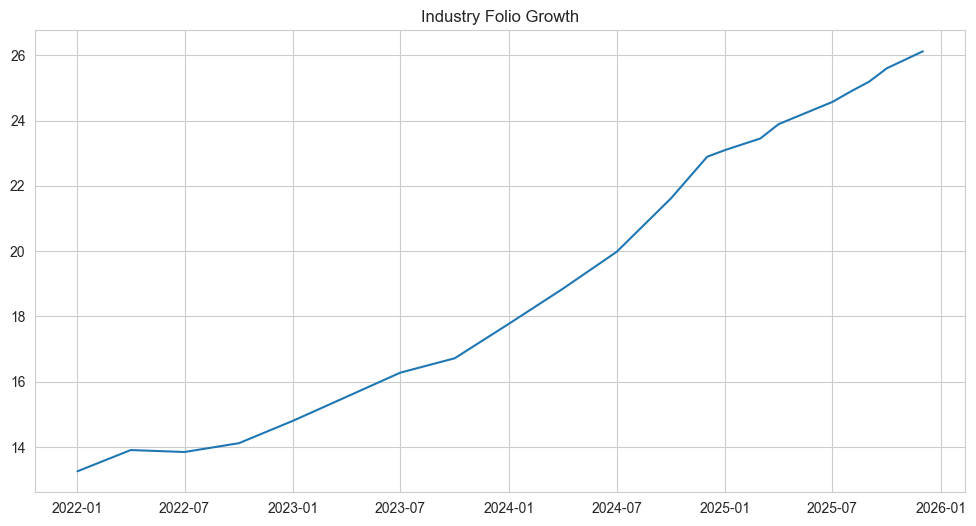

In [ ]:
# folio_growth.png
folios["month"] = pd.to_datetime(
    folios["month"]
)
plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title(
    "Industry Folio Growth"
)

plt.savefig(
    "../reports/folio_growth.png"
)

plt.show()


# EDA Finding 10

Industry folio counts increased significantly between 2022 and 2025, reflecting expanding retail participation.

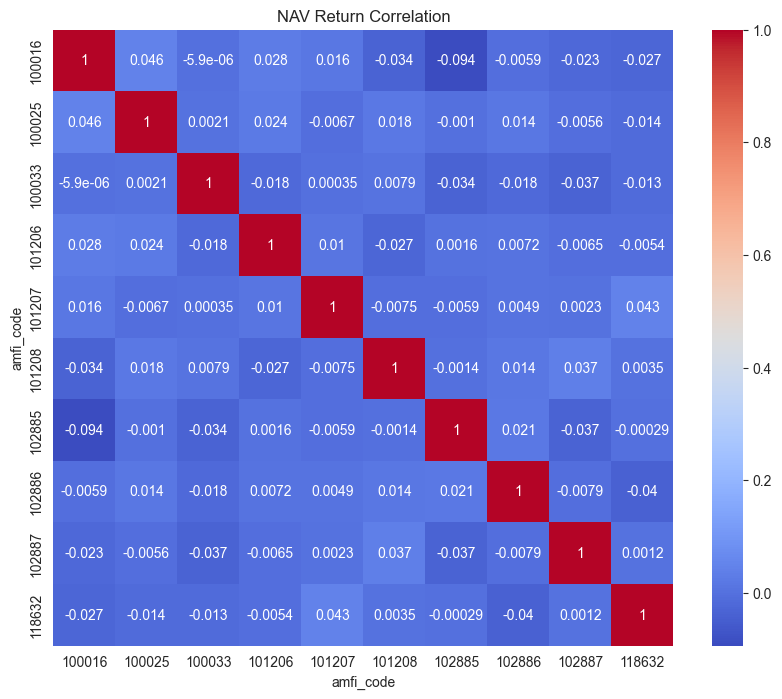

In [ ]:
# correlation_matrix.png
returns = (
    nav.pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
    .pct_change()
)
corr = returns.iloc[:,0:10].corr()
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "NAV Return Correlation"
)

plt.savefig(
    "../reports/correlation_matrix.png"
)

plt.show()

Funds exhibit positive return correlations due to common market exposure.

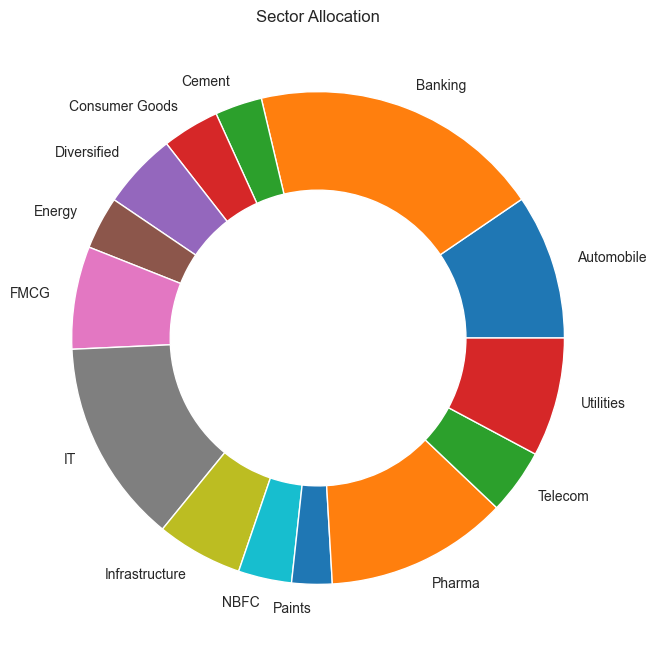

In [ ]:
# sector_donut.png
sector = (
    holdings
    .groupby("sector")
    ["weight_pct"]
    .sum()
)
plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops=dict(width=0.4)
)

plt.title(
    "Sector Allocation"
)

plt.savefig(
    "../reports/sector_donut.png"
)

plt.show()

Financial Services and Technology sectors dominate portfolio allocations.

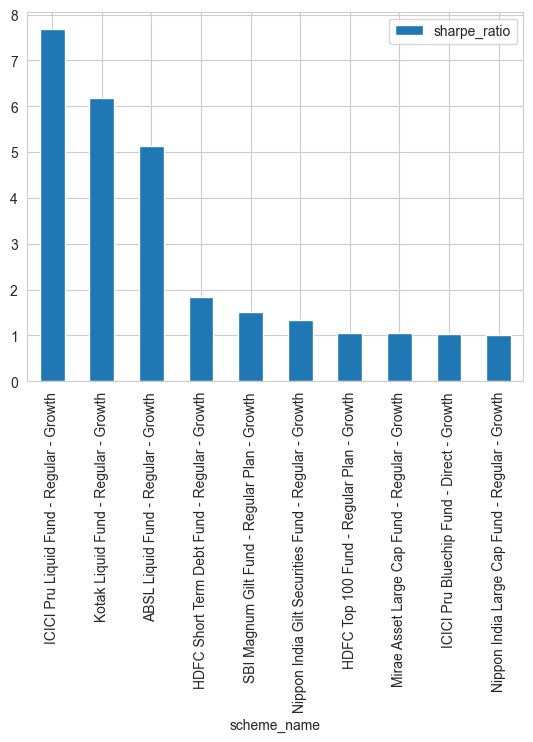

In [ ]:
# top_sharpe.png
performance.nlargest(
    10,
    "sharpe_ratio"
).plot.bar(
    x="scheme_name",
    y="sharpe_ratio"
)

plt.savefig(
    "../reports/top_sharpe.png"
)

Funds with higher Sharpe ratios delivered superior risk-adjusted returns.

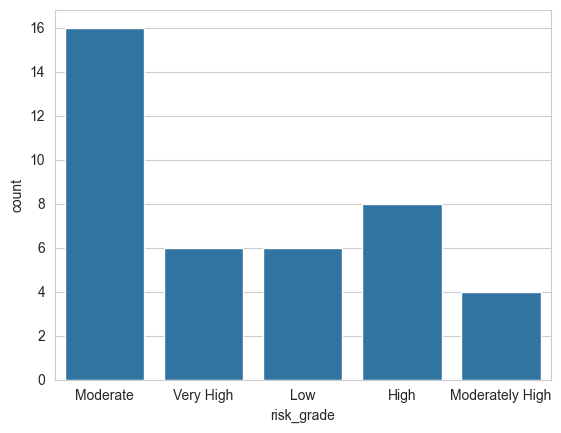

In [ ]:
# risk_grade.png
sns.countplot(
    data=performance,
    x="risk_grade"
)

plt.savefig(
    "../reports/risk_grade.png"
)

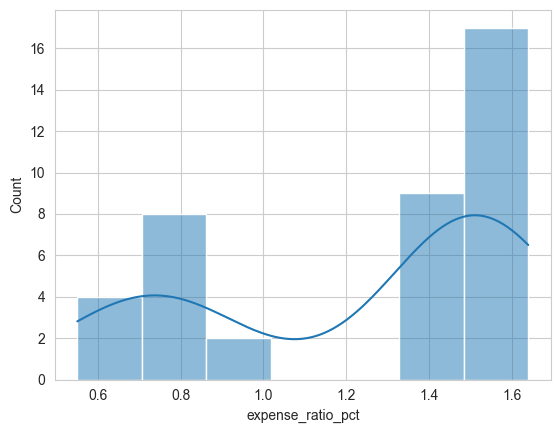

In [ ]:
# expense_ratio_hist.png
sns.histplot(
    performance["expense_ratio_pct"],
    kde=True
)

plt.savefig(
    "../reports/expense_ratio_hist.png"
)

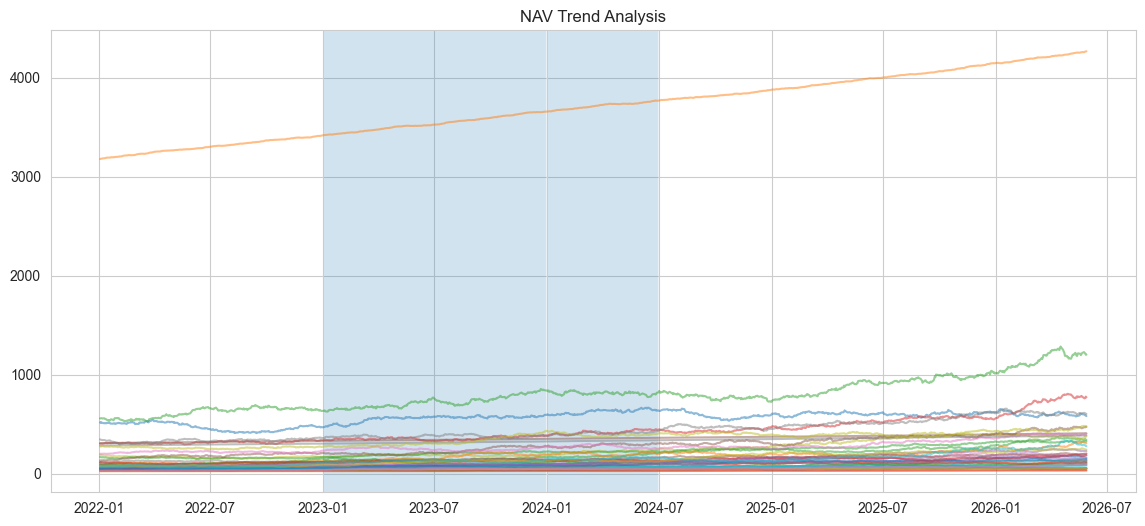

In [ ]:
# benchmark_trends.png
plt.figure(figsize=(14,6))

for fund in nav_plot["scheme_name"].unique():
    temp = nav_plot[
        nav_plot["scheme_name"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        alpha=0.5
    )

plt.axvspan(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-12-31"),
    alpha=0.2,
    label="Bull Run"
)

plt.axvspan(
    pd.Timestamp("2024-01-01"),
    pd.Timestamp("2024-06-30"),
    alpha=0.2,
    label="Correction"
)

plt.title("NAV Trend Analysis")

plt.savefig(
    "../reports/nav_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend"
)

fig.write_image("../reports/sip_trend.png")
plt.show ()


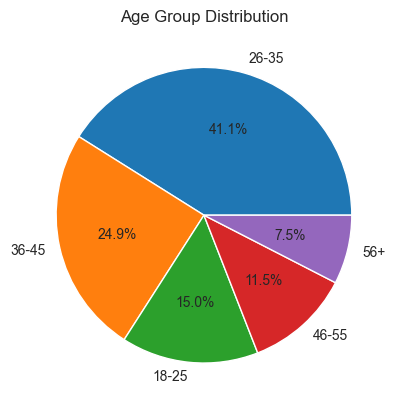

In [ ]:
# age_group_pie.png
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")
plt.savefig("../reports/age_group_pie.png")
plt.show()

# EDA Finding 5

Investors aged 25–40 years represent the largest contributor to mutual fund investments.

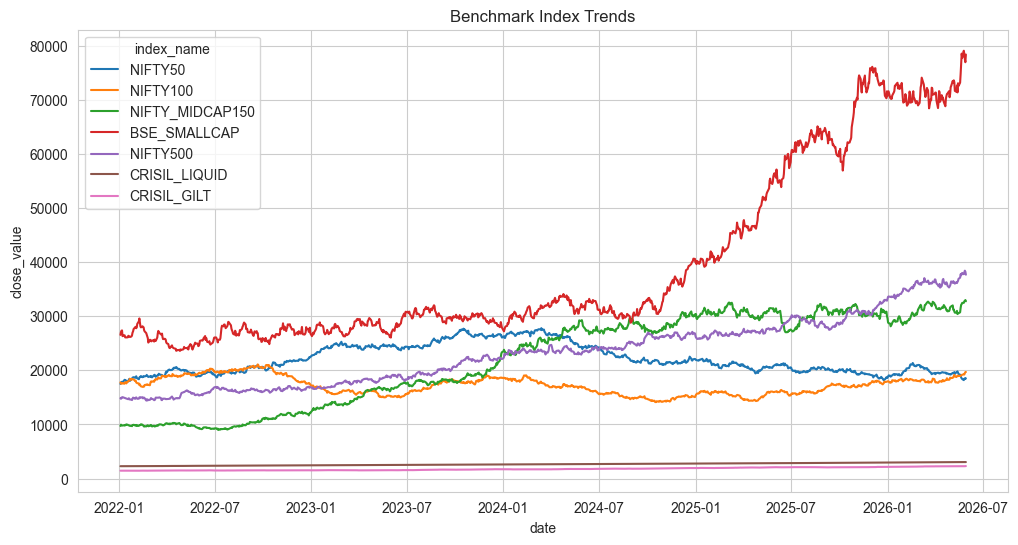

In [47]:

import pandas as pd

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_clean.csv"
)
benchmark["date"] = pd.to_datetime(benchmark["date"])

plt.figure(figsize=(12,6))

sns.lineplot(
    data=benchmark,
    x="date",
    y="close_value",
    hue="index_name"
)

plt.title("Benchmark Index Trends")
plt.savefig("../reports/benchmark_trends.png")
plt.show()

# Conclusion

The Indian mutual fund industry demonstrated strong growth between 2022 and 2025, supported by rising SIP participation, increasing folio counts, and sustained AUM expansion. Equity-oriented schemes remained the preferred investment choice, while portfolio allocations were concentrated in Financial Services and Technology sectors. Overall, the analysis indicates increasing investor confidence and continued growth in the mutual fund ecosystem.